In [1]:
import json

import pandas as pd

from utils import ROOT_PATH
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv(ROOT_PATH / "data" / "tech_mental_health_burnout.csv")

In [3]:
data.head()

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [4]:
data.info(verbose=True)
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  str    
 2   job_role                 150000 non-null  str    
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  str    
 5   work_mode                150000 non-null  str    
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  physical_activi

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,38.025340,5.055010,47.00758,6.127180,4.010893,1.284193,5.500248,5.497537,5.016357,6.499120,2.599833,8.002713,2.101693,5.498163,0.251133,5.785428,4.523763,3.096687,2.114121,0.096333
std,9.510609,2.878602,7.89331,3.783618,1.978316,1.426264,1.956102,1.956915,1.948553,1.192343,1.814880,1.987813,1.300247,1.957432,0.433667,1.331506,1.201506,1.187668,1.112614,0.295049
min,22.000000,0.000000,30.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,30.000000,3.000000,42.00000,3.000000,3.000000,0.000000,4.200000,4.100000,3.700000,5.700000,1.000000,6.700000,1.000000,4.200000,0.000000,4.900000,3.700000,2.200000,1.000000,0.000000
50%,38.000000,5.000000,47.00000,6.000000,4.000000,1.000000,5.500000,5.500000,5.000000,6.500000,2.000000,8.000000,2.000000,5.500000,0.000000,5.800000,4.500000,3.100000,1.900000,0.000000
75%,46.000000,7.000000,52.00000,9.000000,5.000000,2.000000,6.900000,6.800000,6.400000,7.300000,4.000000,9.300000,3.000000,6.800000,1.000000,6.700000,5.300000,3.900000,2.800000,0.000000
max,54.000000,18.500000,84.00000,24.000000,12.000000,5.000000,10.000000,10.000000,10.000000,10.000000,7.000000,16.000000,5.000000,10.000000,1.000000,10.000000,9.600000,8.100000,8.100000,1.000000


In [5]:
# Check the unique values for job_role
unique_jobs = data['job_role'].unique()
unique_jobs

<StringArray>
[ 'Backend Developer', 'Frontend Developer',             'DevOps',
     'Data Scientist',  'Software Engineer',    'Product Manager',
        'QA Engineer',        'ML Engineer']
Length: 8, dtype: str

In [6]:
# Check the burnout_level (one of target classes) distribution

class_distribution = data['burnout_level'].value_counts()
class_distribution

burnout_level
Low         131620
Moderate     18315
High            65
Name: count, dtype: int64

Huge class imbalance regarding the `High` value. <br>
Upsampling/undersampling required

In [7]:
# Check the same for seeks_professional_help

seeks_help_distribution = data['seeks_professional_help'].value_counts()
seeks_help_distribution

seeks_professional_help
0    135550
1     14450
Name: count, dtype: int64

Similar problem happens here, second class makes up around 10% of the whole dataset

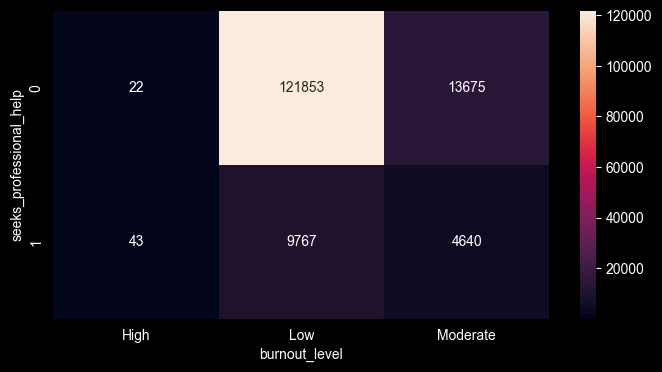

In [8]:
# Changing the burnout_level to numerical for plotting and checking the correlation between two target classes
#
# burnout_encode = {
#     "Low" : 0,
#     "Moderate" : 1,
#     "High" : 2,
# }
#
# data.replace({'burnout_level' : burnout_encode}, inplace=True)
# data['burnout_level'] = data['burnout_level'].astype('int')
def show_y_data_distribution(data: pd.DataFrame):
    data_for_heatmap = data.groupby(['burnout_level', 'seeks_professional_help']).size().reset_index(name='count')
    data_for_heatmap = data_for_heatmap.pivot(columns='burnout_level', values='count', index='seeks_professional_help')
    plt.figure(figsize = (8,4))
    sns.heatmap(data_for_heatmap, annot=True, fmt='g')


show_y_data_distribution(data.copy())

In [ ]:
# As expected, individuals who do not feel the burnout, usually do not seek professional help, while those affected by burnout, often reach out for help - not everyone which is normal in the society, some people are scared etc. Nevertheless both target classes seems to be correlated which will affect the multilabel classification positively.

In [9]:
# Quick test for identifying possible problems when working on this dataset

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

xtrain, ytrain, xtest, ytest = train_test_split( data[['age', 'experience_years', 'overtime_hours', 'job_satisfaction', 'work_life_balance']],  data['burnout_level'], test_size=0.2, random_state=42)


clf = DecisionTreeClassifier()
clf.fit(xtrain, xtest)

y_pred = clf.predict(ytrain)
print(accuracy_score(ytest, y_pred))

confusion_matrix(ytest, y_pred)

0.8047333333333333


array([[    0,     6,     3],
       [   12, 23178,  3132],
       [    7,  2698,   964]])

### Important
While the basic tree classifier got the acc of 80%, which is okay result, from the confusion matrix we can see that the first class was incorrectly predicted at 100% rate, which is not desirable, because that class is the most important and interesting

In [18]:
from typing import  Dict, Any, Tuple
# Create full pipeline for transforming the dataset, including the oversampling and downsampling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE



def create_column_transformer(*args) -> ColumnTransformer | None:
    transformations = [transform for transform in args]
    try:
        column_transformer = ColumnTransformer(transformations, remainder='passthrough')
        column_transformer.set_output(transform="pandas")
        return column_transformer
    except Exception as e:
        print(e)
    return None

def transform_dataset(data_to_transform: pd.DataFrame) -> tuple[pd.DataFrame, dict[Any, Any]]:
    string_columns = data_to_transform.select_dtypes(['string']).columns.tolist()
    string_columns.remove('burnout_level')

    scaled_columns = data_to_transform.select_dtypes(['float']).columns.tolist()
    scaled_columns.extend(['age', 'caffeine_intake', 'deadlines_missed', 'physical_activity_days'])

    standard_scaler = ("scaler", StandardScaler(), scaled_columns)
    one_hot_encoder = ("ohencoder", OneHotEncoder(sparse_output=False), string_columns)

    column_transformer = create_column_transformer(standard_scaler, one_hot_encoder)

    label_encoder = LabelEncoder()

    x = data_to_transform.drop(columns=['burnout_level', 'seeks_professional_help'])
    y = data_to_transform['burnout_level'].astype('str') + '_' + data_to_transform['seeks_professional_help'].astype('str')

    y_encoded = label_encoder.fit_transform(y)
    class_names = dict(enumerate(label_encoder.classes_))


    data_x: pd.DataFrame = column_transformer.fit_transform(x)

    data_x['target'] = y_encoded
    data_x.columns = data_x.columns.str.replace(r'^.*?__', '', regex=True)


    return data_x, class_names


def resample_dataset(data_to_transform: pd.DataFrame, y = None) -> pd.DataFrame:

    data_to_transform.reset_index(drop=True, inplace=True)

    if y is None:
        y = data_to_transform['target']

    _, num_classes = np.unique_counts(y)

    print(num_classes)

    sampling_dict_undersample = {
        2 : 20_000,
    }

    sampling_dict_oversample = {
        0: 800,
        1: 800,
        5: 4000
    }

    random_under_sampler = RandomUnderSampler(random_state=42, sampling_strategy=sampling_dict_undersample)
    smote_sampler = SMOTE(random_state=42, sampling_strategy=sampling_dict_oversample)


    data_x, data_y = random_under_sampler.fit_resample(data_to_transform, y)
    data_x, data_y = smote_sampler.fit_resample(data_x, data_y)

    data_x['target'] = data_y

    return data_x


def recreate_df(x: pd.DataFrame, y) -> pd.DataFrame:
    x['target'] = y
    return x



transformed_data, classes = transform_dataset(data)

x_train, x_test, y_train, y_test = train_test_split(transformed_data.drop('target', axis=1), transformed_data['target'], test_size=0.2, stratify=transformed_data['target'], random_state=42)


x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


train_dataset = resample_dataset(x_train, y_train)



train_dataset.to_csv(ROOT_PATH / "data" / "train_data.csv", index=False, header=True)
recreate_df(x_test, y_test).to_csv(ROOT_PATH / "data" / "test_data.csv", index=False, header=True)
recreate_df(x_val, y_val).to_csv(ROOT_PATH / "data" / "val_data.csv", index=False, header=True)

with open(ROOT_PATH / "data" / "classes_info.json", 'w', newline='') as classes_json:
    classes_json.write(json.dumps(classes, indent=2))


[   14    27 77986  6251  8752  2970]
